In [115]:
import numpy as np
import pandas as pd

# Outliers Detection

Pada tugas lab ini, Anda diberikan dataset harga mobil pada file "boston_house.csv" dan Anda diminta untuk mencari outliers menggunakan beberapa metode outliers detection. Anda dipersilakan untuk menggunakan library yang tersedia untuk membantu pengerjaan.

Berikut penjelasan kolom/fitur yang ada di dataset tersebut:
* **crim**: Tingkat kejahatan per kapita di tiap daerah, yang dapat memengaruhi nilai properti.
* **zn**: Proporsi lahan perumahan yang diatur untuk lot dengan luas lebih dari 25.000 kaki persegi, menunjukkan keberadaan properti residensial besar.
* **indus**: Proporsi lahan yang digunakan untuk kegiatan bisnis non-ritel, menggambarkan tingkat aktivitas industri di daerah tersebut.
* **chas**: Variabel dummy yang menunjukkan apakah properti berbatasan dengan Sungai Charles (1: ya, 0: tidak), yang berpengaruh pada daya tarik kawasan.
* **nox**: Konsentrasi nitrogen oksida (per 10 juta bagian), yang mencerminkan tingkat polusi udara di lingkungan setempat.
* **rm**: Rata-rata jumlah ruangan per tempat tinggal; nilai yang lebih tinggi biasanya menunjukkan rumah yang lebih besar dan bernilai tinggi.
* **age**: Proporsi unit hunian yang dibangun sebelum tahun 1940, memberikan gambaran mengenai usia perumahan di area tersebut.
* **dis**: Rata-rata jarak berbobot ke lima pusat pekerjaan di Boston, mengindikasikan aksesibilitas terhadap lokasi kerja.
* **rad**: Indeks aksesibilitas ke jalan raya radial, menunjukkan kemudahan transportasi di wilayah tersebut.
* **tax**: Tarif pajak properti penuh per $10.000, mencerminkan beban pajak yang harus ditanggung oleh pemilik rumah.
* **ptratio**: Rasio murid-guru di tiap kota, yang menjadi indikator kualitas pendidikan lokal.
* **black**: Nilai yang dihitung berdasarkan proporsi penduduk kulit hitam dengan rumus 1000(Bk - 0.63)², untuk menangkap komposisi rasial lingkungan.
* **lstat**: Persentase penduduk dengan status ekonomi rendah, yang dapat berkorelasi dengan harga properti.
* **medv**: Nilai median rumah yang ditempati oleh pemilik (dalam ribuan dolar).







1. Import dataset boston_house.csv lalu tampilkan preview datanya! (2)

In [116]:
df = pd.read_csv("boston_house.csv")
df

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
1,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21
2,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15
3,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93
4,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,496,0.17899,0.0,9.69,0,0.585,5.670,28.8,2.7986,6,391,19.2,17.60
169,497,0.28960,0.0,9.69,0,0.585,5.390,72.9,2.7986,6,391,19.2,21.14
170,499,0.23912,0.0,9.69,0,0.585,6.019,65.3,2.4091,6,391,19.2,12.92
171,501,0.22438,0.0,9.69,0,0.585,6.027,79.7,2.4982,6,391,19.2,14.33


2. Gunakan metode IQR-based Method (Tukey’s Fence) untuk mendeteksi outliers di seluruh fitur numerik yang ada di dataset. Visualisasikan hasil temuan outliers di masing-masing fitur dan tampilkan ID rumah yang terdeteksi sebagai outliers! (8)

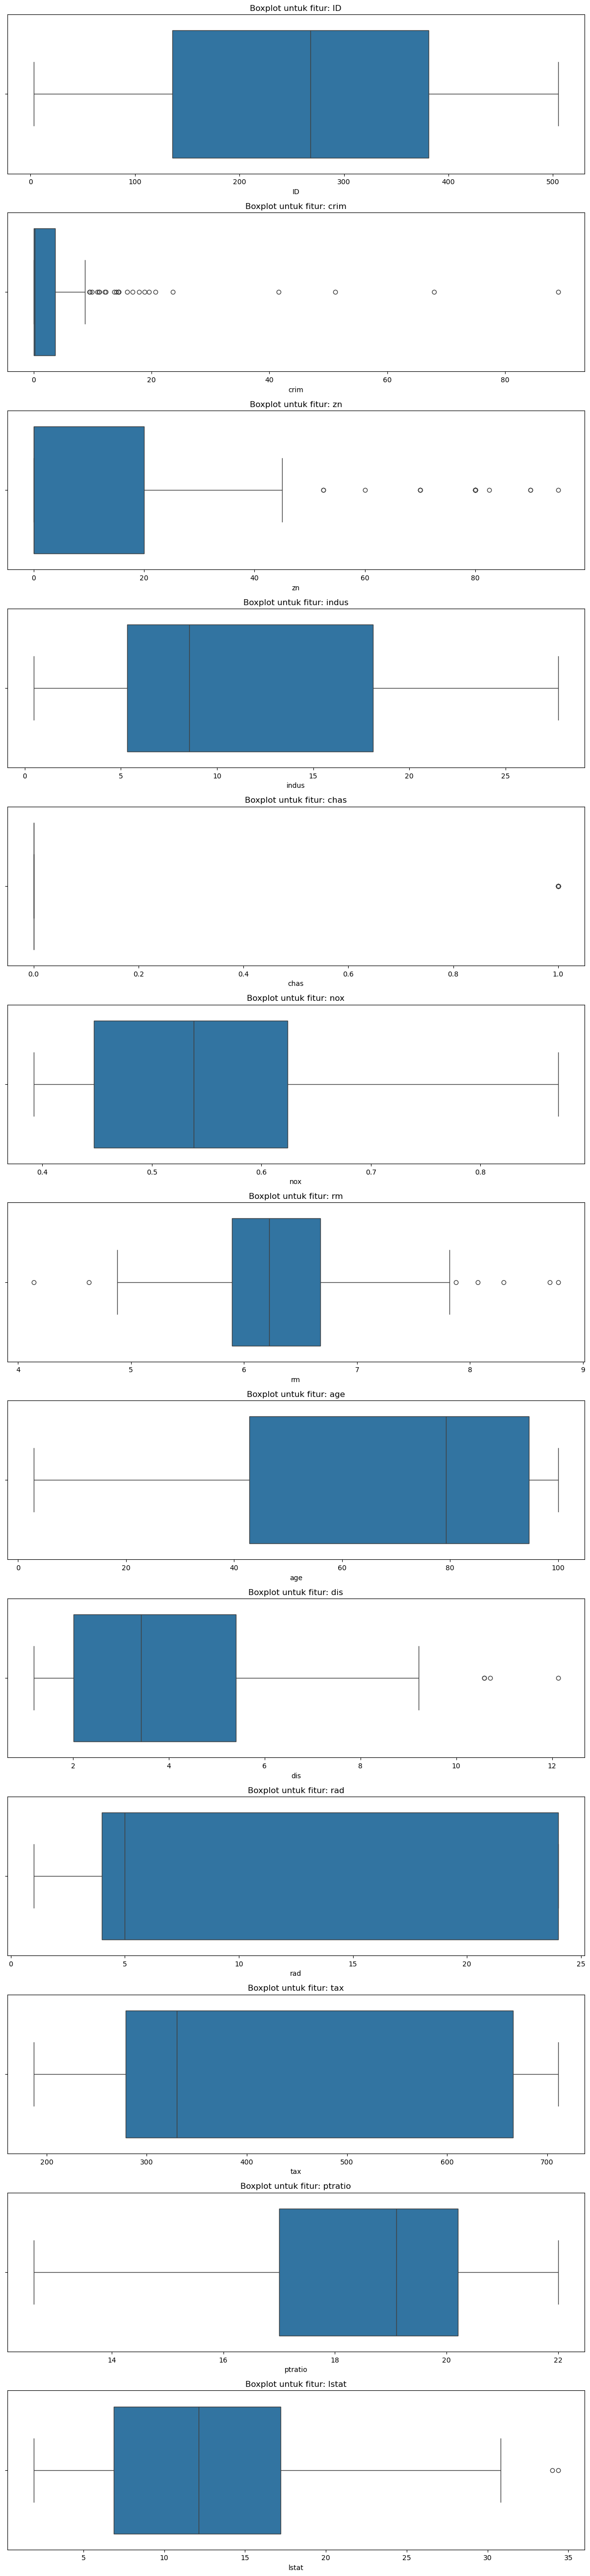

Fitur 'ID' mendeteksi outlier pada ID rumah: []
Fitur 'crim' mendeteksi outlier pada ID rumah: [376, 379, 380, 381, 382, 386, 389, 400, 403, 405, 406, 407, 410, 411, 412, 413, 417, 421, 423, 427, 436, 437, 439, 455]
Fitur 'zn' mendeteksi outlier pada ID rumah: [196, 197, 199, 200, 203, 255, 256, 257, 288, 290, 292, 299, 300, 301, 352, 354, 355, 356]
Fitur 'indus' mendeteksi outlier pada ID rumah: []
Fitur 'chas' mendeteksi outlier pada ID rumah: [153, 156, 163, 210, 211, 213, 219, 220, 221, 270, 277, 278, 364, 365, 370]
Fitur 'nox' mendeteksi outlier pada ID rumah: []
Fitur 'rm' mendeteksi outlier pada ID rumah: [98, 196, 258, 268, 365, 407, 413]
Fitur 'age' mendeteksi outlier pada ID rumah: []
Fitur 'dis' mendeteksi outlier pada ID rumah: [352, 354, 355, 356]
Fitur 'rad' mendeteksi outlier pada ID rumah: []
Fitur 'tax' mendeteksi outlier pada ID rumah: []
Fitur 'ptratio' mendeteksi outlier pada ID rumah: []
Fitur 'lstat' mendeteksi outlier pada ID rumah: [413, 439]


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil nama-nama kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Dictionary untuk menyimpan ID rumah outlier untuk setiap fitur
outliers_dict = {}

# Iterasi untuk setiap kolom numerik dan deteksi outlier dengan metode IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Deteksi outlier: nilai yang berada di bawah lower_bound atau di atas upper_bound
    # Ambil nilai dari kolom 'ID' untuk baris-baris yang merupakan outlier
    outlier_ids = df[(df[col] < lower_bound) | (df[col] > upper_bound)]['ID'].tolist()
    outliers_dict[col] = outlier_ids

# Visualisasikan outlier untuk masing-masing fitur menggunakan boxplot
plt.figure(figsize=(12, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot untuk fitur: {col}")
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# Tampilkan ID rumah yang terdeteksi sebagai outlier untuk setiap fitur
for col, id_list in outliers_dict.items():
    print(f"Fitur '{col}' mendeteksi outlier pada ID rumah: {id_list}")


Principal Component Analysis (PCA) adalah salah satu metode unsupervised learning yang bertujuan untuk mereduksi dimensi (jumlah fitur) dari sebuah dataset. Tujuan utama dari PCA adalah untuk mengurangi jumlah variabel/fitur dalam dataset dengan semaksimal mungkin tetap mempertahankan variasi atau informasi penting dari data dan untuk menemukan kombinasi linear dari fitur-fitur asli yang menghasilkan component (principal components) dengan urutan prioritas berdasarkan seberapa besar variansi yang bisa dijelaskan oleh masing-masing component tersebut.

Sebagai pengingat, PCA bekerja dengan cara memproyeksikan data ke dalam ruang baru yang dihasilkan oleh eigenvectors (disebut principal components). Principal Component pertama (PC1) adalah kombinasi linear fitur-fitur asli yang menjelaskan variansi paling besar dalam data, sedangkan Principal Component kedua (PC2) adalah kombinasi linear berikutnya yang menjelaskan variansi terbesar kedua, dengan syarat tidak berkorelasi (ortogonal) dengan PC1, dan seterusnya untuk PC3, PC4, dst.


Dalam lab ini, tujuan kita menggunakan PCA adalah agar:

- Kita dapat memplot data menjadi 2 dimensi (PC1 dan PC2).
Dengan data 2 dimensi, kita bisa mempermudah visualisasi hasil outlier detection (misalnya, menandai mana data yang dianggap inliers dan outliers di scatter plot 2D).
- Membantu kita untuk memahami bagaimana titik-titik data menyebar berdasarkan component yang paling signifikan.

3. Dengan menggunakan PCA, reduksi fitur dataframe menjadi 2 dimensi dan tampilkan datanya setelah diubah! (5)

          PC1        PC2
0 -163.894036  18.105214
1 -184.021912  18.105723
2  -92.473924  29.677325
3  -91.869111  33.591130
4  -93.418137  22.018287


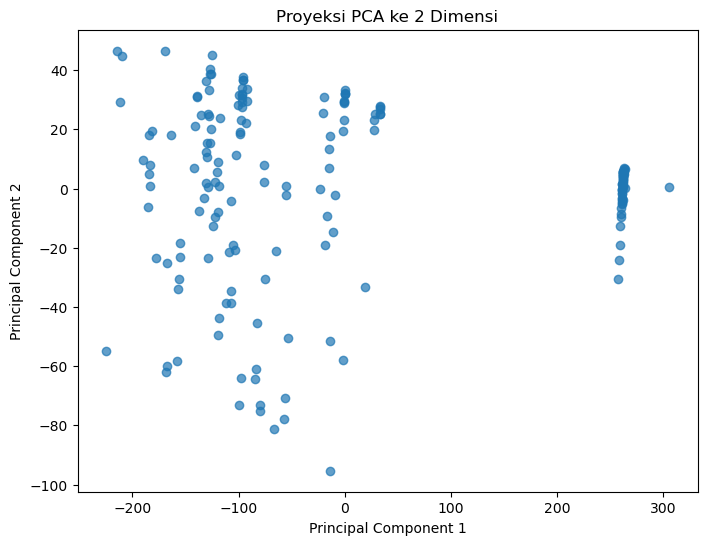

In [118]:
from sklearn.decomposition import PCA

# Jika terdapat kolom 'ID', sebaiknya kita keluarkan dari fitur yang digunakan untuk PCA
if 'ID' in df.columns:
    df_features = df.drop(columns=['ID'])
else:
    df_features = df.copy()

# Inisialisasi PCA untuk mengurangi ke 2 dimensi (PC1 dan PC2)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_features)

# Ubah hasil transformasi ke DataFrame
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# Tampilkan data hasil transformasi (beberapa baris pertama)
print(df_pca.head())

# Visualisasi hasil PCA (opsional)
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Proyeksi PCA ke 2 Dimensi")
plt.show()


4. Gunakan metode Isolation Forest untuk mendeteksi rumah yang termasuk outliers!

* a. Gunakan metode Isolation Forest dengan **n_estimators=100** dan **contamination=0.05** untuk mendeteksi rumah yang termasuk outliers! (5)

In [119]:
from sklearn.ensemble import IsolationForest
# 2. Jika ada kolom 'ID' yang tidak diperlukan untuk deteksi outlier, kita bisa menghapusnya
#    (Abaikan baris ini jika tidak ada kolom 'ID')
if 'ID' in df.columns:
    df_features = df.drop(columns=['ID'])
else:
    df_features = df.copy()

# 3. Inisialisasi Isolation Forest
iso_forest = IsolationForest(n_estimators=100, 
                             contamination=0.05, 
                             random_state=42)

# 4. Melatih model pada data fitur
iso_forest.fit(df_features)

# 5. Memprediksi label outlier (1 = inlier, -1 = outlier)
labels = iso_forest.predict(df_features)

# 6. Menyimpan hasil prediksi ke DataFrame asli
df['outlier_label'] = labels

# 7. Memfilter rumah yang terdeteksi sebagai outliers
df_outliers = df[df['outlier_label'] == -1]

# Menampilkan indeks (atau ID) dan data rumah yang dianggap outlier
print("Indeks rumah yang dianggap outlier:")
print(df_outliers.index.tolist())
print("\nData rumah yang dianggap outlier:")
print(df_outliers)
# Tampilkan ID rumah outliers
print("Rumah yang dianggap outliers (label = -1):")
print(df_outliers['ID'].tolist())


Indeks rumah yang dianggap outlier:
[45, 46, 49, 50, 52, 83, 124, 125, 129]

Data rumah yang dianggap outlier:
      ID      crim    zn  indus  chas    nox     rm    age     dis  rad  tax  \
45   144   4.09740   0.0  19.58     0  0.871  5.468  100.0  1.4118    5  403   
46   145   2.77974   0.0  19.58     0  0.871  4.903   97.8  1.3459    5  403   
49   153   1.12658   0.0  19.58     1  0.871  5.012   88.0  1.6102    5  403   
50   156   3.53501   0.0  19.58     1  0.871  6.152   82.6  1.7455    5  403   
52   163   1.83377   0.0  19.58     1  0.605  7.802   98.2  2.0407    5  403   
83   258   0.61154  20.0   3.97     0  0.647  8.704   86.9  1.8010    5  264   
124  365   3.47428   0.0  18.10     1  0.718  8.780   82.9  1.9047   24  666   
125  370   5.66998   0.0  18.10     1  0.631  6.683   96.8  1.3567   24  666   
129  381  88.97620   0.0  18.10     0  0.671  6.968   91.9  1.4165   24  666   

     ptratio  lstat  outlier_label  
45      14.7  26.42             -1  
46      14.7  

* b. Berdasarkan model yang sudah Anda buat, tampilkan scatterplot yang menunjukkan posisi data yang inliers dan outliers! (5)

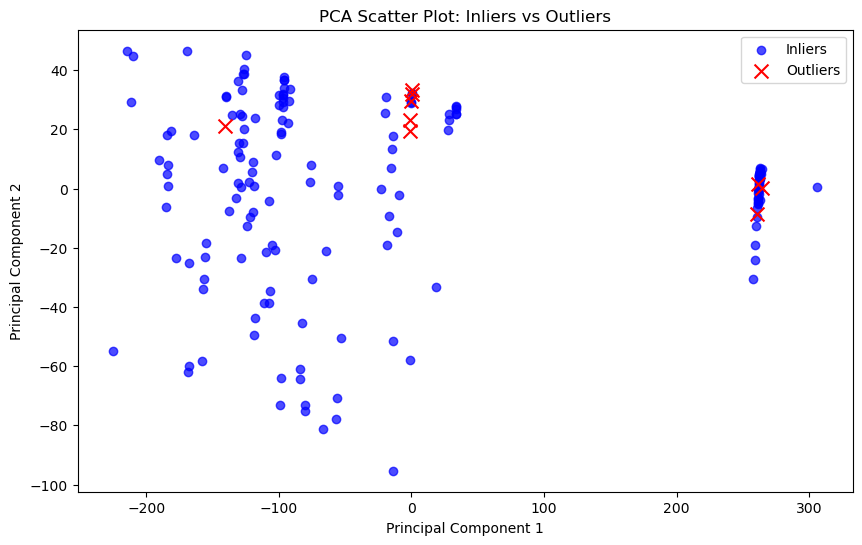

In [120]:
# Menambahkan kolom outlier_label dari df ke df_pca
df_pca['outlier_label'] = df['outlier_label']

# Plot scatter plot dengan warna berbeda untuk inliers dan outliers
plt.figure(figsize=(10, 6))
plt.scatter(df_pca.loc[df_pca['outlier_label'] == 1, 'PC1'],
            df_pca.loc[df_pca['outlier_label'] == 1, 'PC2'],
            c='blue', label='Inliers', alpha=0.7)
plt.scatter(df_pca.loc[df_pca['outlier_label'] == -1, 'PC1'],
            df_pca.loc[df_pca['outlier_label'] == -1, 'PC2'],
            c='red', marker='x', s=100, label='Outliers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot: Inliers vs Outliers')
plt.legend()
plt.show()


* c. Rumah apa saja yang dianggap outliers oleh metode di atas? Tampilkan ID rumah tersebut! (5)

In [121]:
# Tampilkan ID rumah outliers
print("Rumah yang dianggap outliers (label = -1):")
print(df_outliers['ID'].tolist())


Rumah yang dianggap outliers (label = -1):
[144, 145, 153, 156, 163, 258, 365, 370, 381]


5. Gunakan metode DBSCAN dengan minimum points/samples 20 untuk mendeteksi rumah yang termasuk outliers!

* a. Dengan parameter **epsilon=100**, tunjukkan rumah apa saja yang termasuk outliers? Visualisasikan dengan scatterplot dan tampilkan ID rumah outliers tersebut! (5)

Rumah yang dianggap outliers (label = -1):
[]


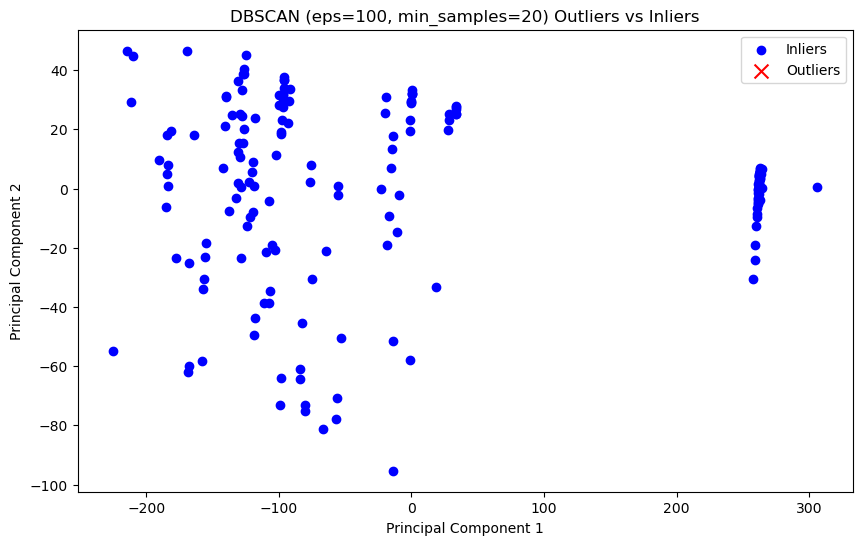

In [122]:
from sklearn.cluster import DBSCAN

# 1. Inisialisasi DBSCAN
dbscan = DBSCAN(eps=100, min_samples=20)

# 2. Fit dan prediksi cluster/outlier
dbscan_labels = dbscan.fit_predict(df_features)

# 3. Tambahkan label hasil DBSCAN ke df dan df_pca
df['dbscan_label'] = dbscan_labels
df_pca['dbscan_label'] = dbscan_labels

# 4. Identifikasi rumah outliers (label = -1)
df_outliers = df[df['dbscan_label'] == -1]
print("Rumah yang dianggap outliers (label = -1):")
print(df_outliers['ID'].tolist())

# 5. Visualisasikan inliers vs outliers di ruang PCA
plt.figure(figsize=(10, 6))

# Inliers (label != -1)
plt.scatter(
    df_pca[df_pca['dbscan_label'] != -1]['PC1'],
    df_pca[df_pca['dbscan_label'] != -1]['PC2'],
    color='blue',
    label='Inliers'
)

# Outliers (label = -1)
plt.scatter(
    df_pca[df_pca['dbscan_label'] == -1]['PC1'],
    df_pca[df_pca['dbscan_label'] == -1]['PC2'],
    color='red',
    marker='x',
    s=100,
    label='Outliers'
)

plt.title("DBSCAN (eps=100, min_samples=20) Outliers vs Inliers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


* b. Dengan parameter <strike>**epsilon=70**</strike> **epsilon=50**, tunjukkan rumah apa saja yang termasuk outliers? Visualisasikan dengan scatterplot dan tampilkan ID rumah outliers tersebut! (5)

Rumah yang dianggap outliers (label = -1):
[42, 126, 185, 186, 189, 200, 203, 257, 300, 352, 354, 490]


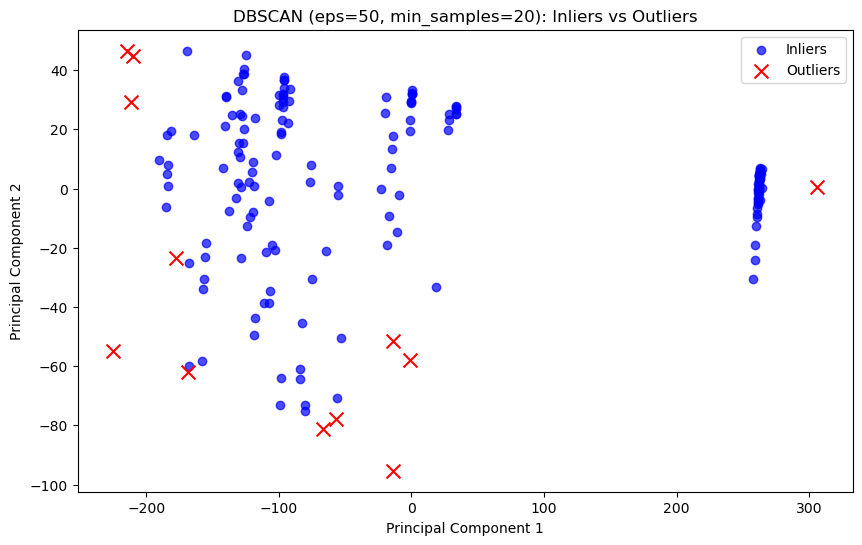

In [123]:
# Inisialisasi DBSCAN dengan parameter eps=50 dan min_samples=20
dbscan = DBSCAN(eps=50, min_samples=20)

# Fit dan prediksi cluster/outlier menggunakan fitur asli
dbscan_labels = dbscan.fit_predict(df_features)

# Tambahkan label hasil DBSCAN ke DataFrame asli dan DataFrame hasil PCA
df['dbscan_label'] = dbscan_labels
df_pca['dbscan_label'] = dbscan_labels

# Filter rumah yang dianggap outlier (label = -1)
df_outliers = df[df['dbscan_label'] == -1]

print("Rumah yang dianggap outliers (label = -1):")
print(df_outliers['ID'].tolist())

# Visualisasi inliers dan outliers pada scatter plot hasil PCA
plt.figure(figsize=(10, 6))
# Inliers
plt.scatter(
    df_pca.loc[df_pca['dbscan_label'] != -1, 'PC1'],
    df_pca.loc[df_pca['dbscan_label'] != -1, 'PC2'],
    c='blue', alpha=0.7, label='Inliers'
)
# Outliers
plt.scatter(
    df_pca.loc[df_pca['dbscan_label'] == -1, 'PC1'],
    df_pca.loc[df_pca['dbscan_label'] == -1, 'PC2'],
    c='red', marker='x', s=100, label='Outliers'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN (eps=50, min_samples=20): Inliers vs Outliers")
plt.legend()
plt.show()


6. Apa yang dapat Anda simpulkan dari ketiga metode outliers detection yang sudah dilakukan? Rumah apa yang selalu muncul sebagai outliers? (10)

**Jawaban**

Ketiga metode outlier detection yang telah dilakukan—yaitu metode IQR (Tukey’s Fence), Isolation Forest, dan DBSCAN—masing-masing mendeteksi outlier dengan pendekatan yang berbeda:

- **Metode IQR (Tukey’s Fence):**  
  Deteksi outlier dilakukan secara per fitur, dengan mengidentifikasi nilai yang terlalu jauh dari kuartil pertama dan ketiga. Hasilnya pun berbeda antar fitur; misalnya, fitur *crim*, *zn*, *chas*, dan *rm* menunjukkan sejumlah outlier, sedangkan beberapa fitur seperti *indus*, *nox*, *age*, *rad*, *tax*, dan *ptratio* tidak menunjukkan adanya outlier. Hasil ini mencerminkan bahwa outlier bisa muncul pada beberapa dimensi data saja.

- **Isolation Forest:**  
  Metode ini mendeteksi outlier secara global dengan mengisolasi titik data yang memiliki karakteristik ekstrim dalam konteks keseluruhan dataset. Hasilnya menghasilkan daftar outlier (ID rumah) seperti [144, 145, 153, 156, 163, 258, 365, 370, 381] yang didasarkan pada pola multivariat.

- **DBSCAN:**  
  Karena DBSCAN bergantung pada parameter kepadatan, dengan **eps=100** tidak ditemukan outlier karena radius pencarian yang terlalu besar. Namun, dengan **eps=50** (dan min_samples=20) DBSCAN mendeteksi outlier yang berbeda, misalnya rumah dengan ID [42, 126, 185, 186, 189, 200, 203, 257, 300, 352, 354, 490]. Hal ini menunjukkan bahwa parameter yang dipilih sangat berpengaruh, dan DBSCAN cenderung menangkap outlier sebagai titik-titik yang berada di area dengan kepadatan rendah.

**Simpulan Umum:**  
- Masing-masing metode menghasilkan set outlier yang berbeda karena perbedaan pendekatan (statistik univariat vs. analisis multivariat vs. kepadatan lokal).  
- Tidak ada satu rumah pun yang muncul sebagai outlier di ketiga metode secara seragam.  
- Namun, jika dilihat dari metode IQR dan Isolation Forest, rumah dengan **ID 365** dan **ID 370** cukup konsisten muncul sebagai outlier, yang menunjukkan bahwa rumah tersebut memiliki karakteristik ekstrim dalam beberapa fitur (misalnya pada *chas* dan *rm*).  
- Sementara itu, DBSCAN dengan **eps=50** mengungkapkan outlier yang berbeda, sehingga perbedaan hasil ini menggarisbawahi pentingnya pemilihan metode dan parameter dalam analisis outlier.

Dengan demikian, pemilihan metode outlier detection harus disesuaikan dengan tujuan analisis dan karakteristik data yang ingin diungkap, karena setiap metode memiliki sensitivitas dan fokus yang berbeda terhadap pola data.

# Association Rule Mining

Association rule mining merupakan suatu teknik yang menemukan hubungan yang menarik antar item pada data yang besar. Salah satu penerapannya adalah untuk mengetahui hubungan antar item pada suatu transaksi. Analisis asosiasi dapat memberikan insight mengenai pola belanja pelanggan dengan melihat produk-produk yang umum dibeli dalam suatu transaksi. Salah satu algoritma yang umumnya digunakan adalah Apriori.

Apriori mencari aturan atau hubungan antar item transaksi dengan prinsip subset pada itemset yang sering muncul (frequent itemset) juga sering muncul (frequent). Sebaliknya, superset dari itemset non-frequent juga harus non-frequent.

Pada tugas lab ini, Anda diberikan dataset transaksi belanja pada sebuah supermarket pada file "basket.csv" dan Anda diminta untuk menerapkan Apriori untuk menjawab soal-soal yang diberikan. Anda dipersilakan untuk menggunakan library yang tersedia untuk penerapan Apriori dan library pendukung lainnya (contoh: pandas). Pada soal-soal di bawah ini gunakan threshold sebagai berikut:
- Minimum support: 0.005
- Minimum confidence: 0.07
- Minimum lift: 1

## Pertanyaan

1. Load data "basket.csv" yang berisi daftar transaksi belanja, kemudian transformasikan ke dalam bentuk encode transaksi sehingga nama kolom menjadi nama produk dan isi nya adalah True jika pada transaksi tersebut ada produk terkait, dan False jika tidak ada produk terkait. (5)

In [124]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Baca dataset (tanpa header, misalnya)
df_basket = pd.read_csv("basket.csv", header=None)

# Ubah setiap baris menjadi list (mengabaikan NaN)
transactions = df_basket.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

# Lakukan encoding transaksi menggunakan TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Tampilkan beberapa baris hasil encoding
print(df_encoded.head())


   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisky  white bread  \
0  ...   False 

2. Tentukan frequent itemsets dengan menggunakan Apriori, dengan minimum support 0.005. Tentukan juga banyak item dalam setiap itemset dan urutkan frequent itemsets dari support yang tertinggi! (10)
  
Hint: ekspektasi output adalah kolom support, itemsets, dan length

In [125]:
from mlxtend.frequent_patterns import apriori

# Cari frequent itemsets dengan minimum support 0.005
frequent_itemsets = apriori(df_encoded, min_support=0.005, use_colnames=True)

# Tambahkan kolom 'length' untuk mengetahui jumlah item dalam setiap itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Urutkan berdasarkan support secara menurun
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

# Tampilkan hasil (kolom support, itemsets, dan length)
print(frequent_itemsets[['support', 'itemsets', 'length']])


      support                         itemsets  length
87   0.157923                     (whole milk)       1
53   0.122101               (other vegetables)       1
66   0.110005                     (rolls/buns)       1
75   0.097106                           (soda)       1
88   0.085879                         (yogurt)       1
..        ...                              ...     ...
96   0.005280        (whole milk, frankfurter)       2
124  0.005213         (tropical fruit, yogurt)       2
95   0.005146  (other vegetables, frankfurter)       2
45   0.005012                     (mayonnaise)       1
107  0.005012               (whole milk, pork)       2

[126 rows x 3 columns]


3. Jelaskan 2 item yang memiliki nilai support tertinggi! (5)

In [126]:
# Filter itemset dengan satu item saja
single_itemsets = frequent_itemsets[frequent_itemsets['length'] == 1]

# Urutkan dan ambil dua item teratas
top_two = single_itemsets.sort_values(by='support', ascending=False).head(2)
print("Dua item dengan support tertinggi:")
print(top_two)


Dua item dengan support tertinggi:
     support            itemsets  length
87  0.157923        (whole milk)       1
53  0.122101  (other vegetables)       1


Dua item dengan support tertinggi adalah:

- **Whole milk** dengan support 0.157923, yang berarti sekitar 15,79% transaksi mengandung whole milk. Ini menunjukkan bahwa whole milk merupakan produk yang sangat populer di antara pelanggan, mungkin karena dianggap sebagai kebutuhan pokok atau produk favorit.

- **Other vegetables** dengan support 0.122101, artinya sekitar 12,21% transaksi mengandung other vegetables. Produk ini juga cukup sering dibeli, mengindikasikan bahwa pelanggan cenderung memilih sayuran sebagai bagian penting dari pola belanja mereka.

Kedua item ini menonjol karena frekuensi kemunculannya yang tinggi dalam transaksi, sehingga dapat menjadi indikator penting dalam analisis pola belanja di supermarket.

4. Tentukan association rules dari frequent itemsets dengan kriteria minimum confidence 0.07. (10)

In [127]:
from mlxtend.frequent_patterns import association_rules

# Tentukan aturan asosiasi dengan minimum confidence 0.07
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.07)

# Tampilkan aturan (misalnya, kolom antecedents, consequents, support, confidence, lift)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


           antecedents         consequents   support  confidence      lift
0         (whole milk)  (other vegetables)  0.014837    0.093948  0.769430
1   (other vegetables)        (whole milk)  0.014837    0.121511  0.769430
2         (whole milk)        (rolls/buns)  0.013968    0.088447  0.804028
3         (rolls/buns)        (whole milk)  0.013968    0.126974  0.804028
4         (whole milk)              (soda)  0.011629    0.073635  0.758296
5               (soda)        (whole milk)  0.011629    0.119752  0.758296
6         (whole milk)            (yogurt)  0.011161    0.070673  0.822940
7             (yogurt)        (whole milk)  0.011161    0.129961  0.822940
8   (other vegetables)        (rolls/buns)  0.010559    0.086481  0.786154
9         (rolls/buns)  (other vegetables)  0.010559    0.095990  0.786154
10  (other vegetables)              (soda)  0.009691    0.079365  0.817302
11              (soda)  (other vegetables)  0.009691    0.099794  0.817302
12           (sausage)   

5. Berapa support dan confidence untuk aturan "jika pelanggan membeli sausage, mereka cenderung membeli rolls/buns juga"? (5)

In [128]:
# Pastikan nama item sesuai dengan yang ada di dataset, misalnya 'sausage' dan 'rolls/buns'
rule_sausage_rolls = rules[(rules['antecedents'] == frozenset({'sausage'})) & 
                           (rules['consequents'] == frozenset({'rolls/buns'}))]
print("Aturan: Jika membeli sausage, maka membeli rolls/buns:")
print(rule_sausage_rolls[['support', 'confidence']])

Aturan: Jika membeli sausage, maka membeli rolls/buns:
     support  confidence
36  0.005347    0.088594


6. Tentukan asosiasi positif berdasarkan lift dan urutkan asosiasi dari nilai lift tertinggi! (5)

In [129]:
positive_rules = rules.sort_values(by='lift', ascending=False)
print("Aturan asosiasi positif (lift >= 1) diurutkan dari yang tertinggi:")
print(positive_rules[['antecedents', 'consequents', 'lift']])


Aturan asosiasi positif (lift >= 1) diurutkan dari yang tertinggi:
           antecedents         consequents      lift
42       (frankfurter)  (other vegetables)  1.116150
31           (sausage)            (yogurt)  1.108986
30           (sausage)              (soda)  1.014975
20      (bottled beer)        (whole milk)  0.999330
12           (sausage)        (whole milk)  0.939663
33        (newspapers)        (whole milk)  0.913926
38     (domestic eggs)        (whole milk)  0.901341
41    (tropical fruit)            (yogurt)  0.895720
40       (frankfurter)        (whole milk)  0.885388
43              (pork)        (whole milk)  0.855703
23         (pip fruit)        (whole milk)  0.854071
22      (citrus fruit)        (whole milk)  0.852259
25     (shopping bags)        (whole milk)  0.844887
17            (yogurt)        (rolls/buns)  0.827697
18        (rolls/buns)            (yogurt)  0.827697
6         (whole milk)            (yogurt)  0.822940
7             (yogurt)        (w

7. Apakah ada kecenderungan ketika pelanggan membeli frankfurter dan other vegetables, maka cenderung akan membeli rolls/buns juga? Jika ada, tampilkan support, confidence, dan lift nya! (5)

In [130]:
# Filter aturan yang antecedents mengandung kedua item dan consequents tepat {rolls/buns}
rule_frankfurter = rules[
    (rules['antecedents'].apply(lambda x: {'frankfurter', 'other vegetables'}.issubset(x))) &
    (rules['consequents'] == frozenset({'rolls/buns'}))
]

if not rule_frankfurter.empty:
    print("Aturan untuk pembelian 'frankfurter' dan 'other vegetables' => 'rolls/buns':")
    print(rule_frankfurter[['support', 'confidence', 'lift']])
else:
    print("Tidak ditemukan aturan yang memenuhi kriteria tersebut.")


Tidak ditemukan aturan yang memenuhi kriteria tersebut.


8. Visualisasikan aturan asosiasi yang telah Anda peroleh dalam bentuk graph! (5)

Hint:
- Pastikan Anda telah memilih aturan asosiasi dengan minimum support 0.005, minimum confidence 0.07, dan minimum lift 1.
- Gunakan networkx untuk menggambar directed graph yang memperlihatkan aturan asosiasi antar item.

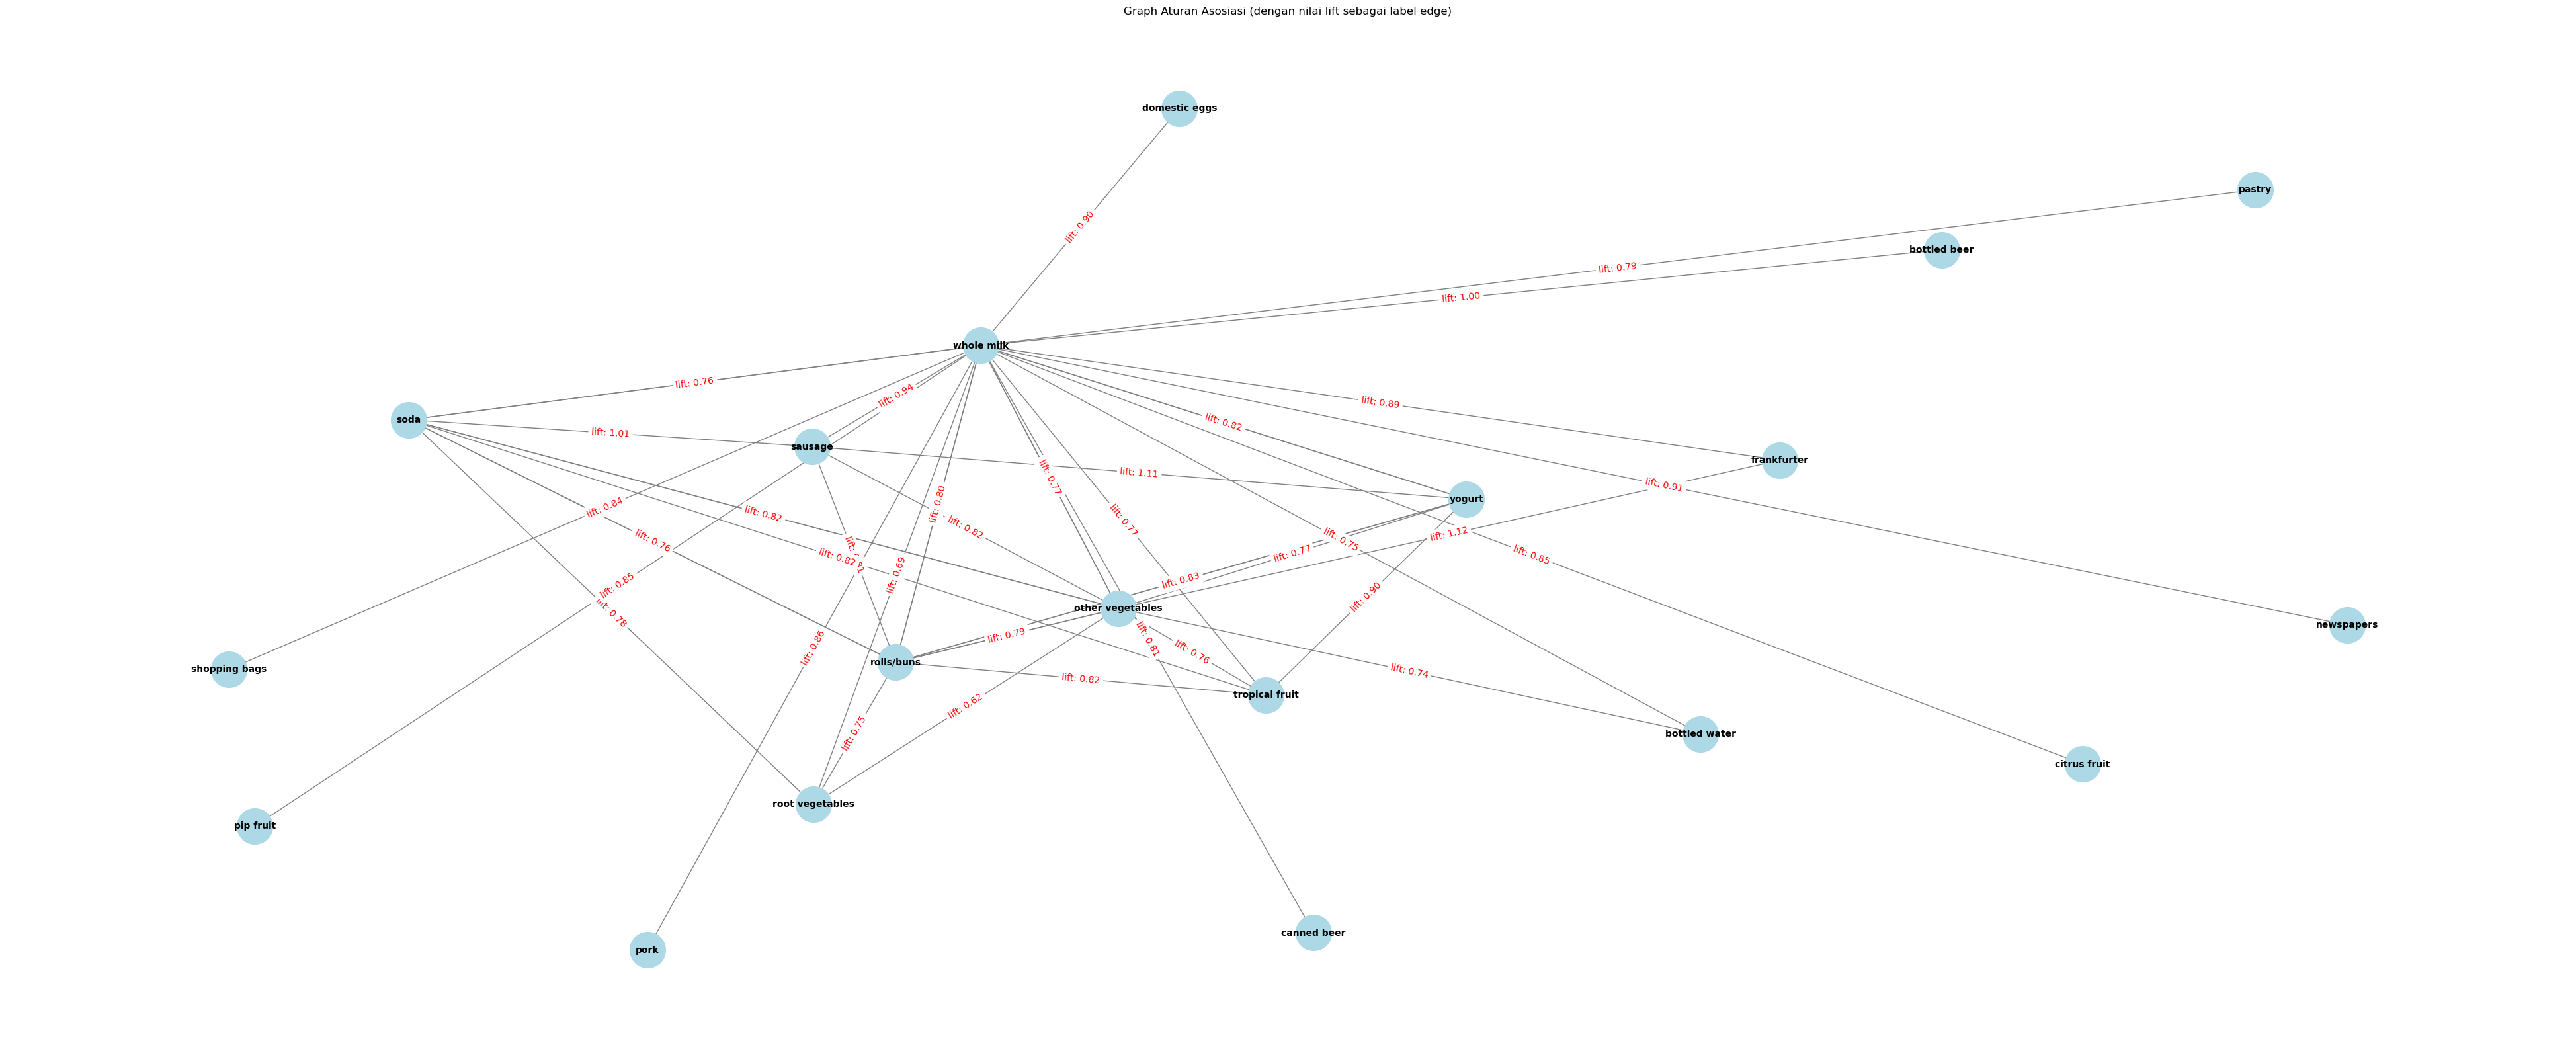

In [131]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Tambahkan edge untuk setiap aturan; gunakan lift sebagai label edge (bisa juga menambahkan support/confidence)
for idx, row in rules.iterrows():
    antecedent = ', '.join(sorted(list(row['antecedents'])))
    consequent = ', '.join(sorted(list(row['consequents'])))
    G.add_edge(antecedent, consequent, weight=row['lift'], support=row['support'], confidence=row['confidence'])

plt.figure(figsize=(50, 20))
pos = nx.spring_layout(G, k=0.5, seed=42)  # Posisi layout

# Gambar node
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue')

# Gambar edge dengan panah
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')

# Gambar label node
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Gambar label edge (menggunakan nilai lift)
edge_labels = {(u, v): f"lift: {d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Graph Aturan Asosiasi (dengan nilai lift sebagai label edge)")
plt.axis('off')
plt.show()
